LOADING THE DATASET

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/DL_Balanced_dataset.csv')
df.shape

(750000, 2)

In [3]:
df.columns

Index(['review', 'rating'], dtype='object')

In [4]:
df['review']=df['review'].astype(str).str.lower()

In [5]:
df.head(5)

,review,rating
0,i must be missing something here or am incredi...,1.0
1,this computer has stopped working how do i ret...,1.0
2,horribal this movie was terrible not one of th...,1.0
3,i purchased this for my kindle fire but you ne...,1.0
4,cables do not match other customerreview pictu...,1.0


In [6]:
df['rating'].value_counts()

,count
rating,
1.0,150000
2.0,150000
3.0,150000
4.0,150000
5.0,150000


In [7]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = df[df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. lasted hour got very hot then it started to melt downbr stick with oem products from hp i should know better

2. it doesnt fit the nexus nd gen

3. the mouse pointer doesnt track your movement properly you switch it off and then turn it on again to make it work its very frustrating

4. i owned the echo gb which i loved until like hundreds and hundreds of others the screen went dark in under a year livescribes response buy another onebr because i needed this solution to work for aerospace i foolishly bought the hoping id be lucky and it may workbr in the three meetings we tried to use it for it ran very hot omitted much of the recordings and created a low electronic hum for much of the restbr i still have the echo i paid for and because livescribe refuses to even let me pay a fair price to get the display replaced which i shouldnt have to at all as with so many others its a wastebr its sad to see useful technology ruined by poor quality

5. 

In [ ]:
# Create a word count column (but don't modify the dataset permanently)
word_stats = (
    df.assign(word_count=df['review'].str.split().apply(len))
      .groupby('rating')['word_count']
      .agg(['min', 'max'])
      .reset_index()
)

print(word_stats)


   rating  min   max
0     1.0    1  4627
1     2.0    1  5003
2     3.0    1  7467
3     4.0    1  8363
4     5.0    1  7308


In [8]:
df['rating']=df['rating'].astype(int)

BIDIRECTIONAL LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,461 (10.15 MB)

 Trainable params: 2,659,461 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 89s 20ms/step - accuracy: 0.4664 - loss: 1.2107 - val_accuracy: 0.5383 - val_loss: 1.0475
Epoch 2/5
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 142s 21ms/step - accuracy: 0.5569 - loss: 1.0199 - val_accuracy: 0.5528 - val_loss: 1.0160
Epoch 3/5
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 137s 20ms/step - accuracy: 0.5871 - loss: 0.9538 - val_accuracy: 0.5573 - val_loss: 1.0120
Epoch 4/5
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 143s 20ms/step - accuracy: 0.6135 - loss: 0.8990 - val_accuracy: 0.5577 - val_loss: 1.0305
Epoch 5/5
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 83s 20ms/step - accuracy: 0.6418 - loss: 0.8427 - val_accuracy: 0.5497 - val_loss: 1.0717
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step
Accuracy: 0.5498
Classification Report:

              precision    recall  f1-score   support

           1       0.66      0.62      0.64     30000
           2       0.45      0.52      0.48     30000
           3       0.46      0.48      0.47     30000
           4       0.52      0.48      0

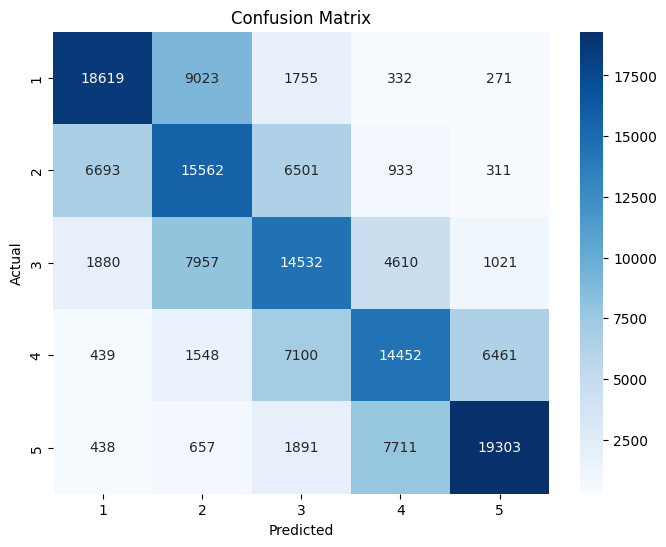

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# Prepare data
X = df['review']
y = df['rating']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    stratify=y_categorical,
    random_state=42
)

# Tokenization and padding
max_words = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


# Build BiLSTM Model
embedding_dim = 128
lstm_units = 64
num_classes = y_categorical.shape[1]

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
model.add(Bidirectional(LSTM(lstm_units)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Build model to show correct summary
model.build(input_shape=(None, max_len))
model.summary()

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model

history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)


# Evaluate Model
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precision, Recall, F1-Score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in le.classes_]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


SAVING THE MODEL

In [10]:
model.save('Model_B.h5')

In [11]:
import pickle
with open('tokenizer2.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 3. Save Label Encoder
with open('label_encoder2.pkl', 'wb') as f:
    pickle.dump(le, f)


MODEL A ON BALANCCED DATASET

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step
Accuracy: 0.55782

Classification Report:
              precision    recall  f1-score   support

           1       0.59      0.82      0.68     30000
           2       0.58      0.22      0.32     30000
           3       0.49      0.48      0.48     30000
           4       0.49      0.59      0.54     30000
           5       0.65      0.68      0.66     30000

    accuracy                           0.56    150000
   macro avg       0.56      0.56      0.54    150000
weighted avg       0.56      0.56      0.54    150000



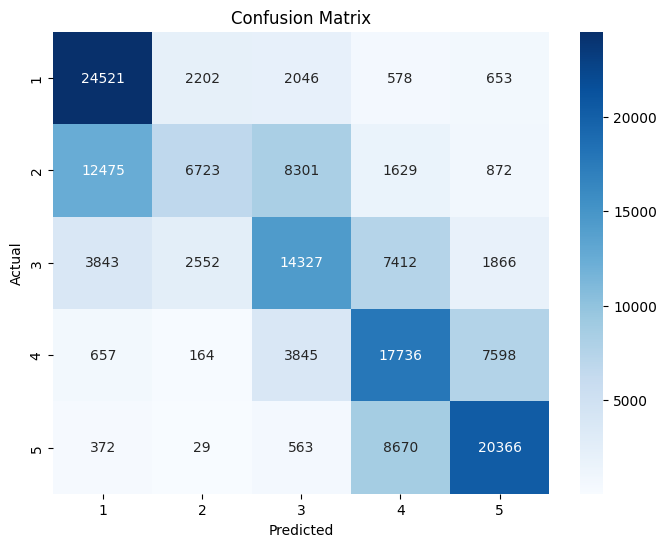

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle




X = df['review']
y = df['rating']

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
y_encoded = le.fit_transform(y)

# --- Stratified split ---
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# --- One-hot encode (if needed for model) ---
from tensorflow.keras.utils import to_categorical
y_test = to_categorical(y_test_raw)

# --- Load model and tokenizer and label encoder ---
model = load_model('Model_A.h5')

with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)





# --- Prepare test data ---
max_len = 150  # must match training
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# --- Predict ---
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw   # original label numeric

# --- Evaluation Metrics ---
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_.astype(str)))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
